ANN Classification

Importing

In [45]:
# --- Imports ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from functools import reduce
import scikeras
from tensorflow.keras import regularizers

# Import confusion_matrix and classification_report for model evaluation
from sklearn.metrics import accuracy_score
# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler, QuantileTransformer
# Import train_test_split for splitting the dataset into training and test sets
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
# Import permutation_importance for calculating feature importance  
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix, classification_report

### Tensorflow and Keras imports ###
# Ensure any imports from "keras" resolve to tf.keras (avoids mixing standalone Keras with tf.keras)
import tensorflow as tf


# Import Keras namespace for convenience (you also have `from tensorflow import keras` below)
from tensorflow import keras

from tensorflow.keras import layers
# Import Dense and Activation layers for neural network architecture
from tensorflow.keras.layers import Dense, Activation
# Import Sequential for linear stacking of layers
from keras.models import Sequential


# Import KerasClassifier to make Keras models compatible with scikit-learn
from scikeras.wrappers import KerasClassifier

# set print options for pandas
pd.set_option('display.max_columns', None)

## some stuff for making pretty plots
from matplotlib import rcParams
from cycler import cycler
## Set plotting style and print options
sns.set_theme()
sns.set_style("whitegrid")
sns.set_context("paper") #Possible are paper, notebook, talk and poster
# Set figure format
wide_format, square_format = False, True
if wide_format:
    d = {'lines.linewidth': 2, 'axes.titlesize': 18, 'axes.labelsize': 18, 'xtick.labelsize': 12, 'ytick.labelsize': 12,\
     'legend.fontsize': 15, 'font.family': 'serif', 'figure.figsize': (9,6)}
if square_format:
    d = {'lines.linewidth': 2, 'axes.titlesize': 16, 'axes.labelsize': 14, 'xtick.labelsize': 10, 'ytick.labelsize': 10,\
     'legend.fontsize': 12, 'font.family': 'serif', 'figure.figsize': (6,6)}
    
d_colors = {'axes.prop_cycle': cycler(color = ['teal', 'navy', 'coral', 'plum', 'purple', 'olivedrab',\
         'black', 'red', 'cyan', 'yellow', 'khaki','lightblue'])}
rcParams.update(d)
rcParams.update(d_colors)

In [46]:
def plot_classificiation_results(history):

    # make a list of the train and val metrics
    metrics = list(history.history.keys())
    
    # make lists of train and val metrics
    val_metrics = [entry for entry in metrics if entry.startswith('val_')]
    train_metrics = [entry for entry in metrics if not entry.startswith('val_')]

    # the number of metrics to plot
    Nmetrics = len(val_metrics)
    width = 6 * Nmetrics

    fig, ax = plt.subplots(ncols = Nmetrics, figsize=(width, 6))

    # plot the train and val results for each metric
    for i, axx in enumerate(ax):
        ax[i].plot(history.history[train_metrics[i]], label='train', alpha = 0.7)  
        ax[i].plot(history.history[val_metrics[i]], label='validation', alpha = 0.7)
        ax[i].set_ylabel(f'{train_metrics[i].capitalize()}')
        ax[i].set_xlabel('Epoch')
        ax[i].legend(loc='best')
    fig.tight_layout()
    return fig, ax 

def evaluate_binary_classification_results(model, X_train, y_train, X_val, y_val, X_test = None, y_test = None,\
                                           metrics = [accuracy_score], metric_names = ['Accuracy']):
    
    # make predictions
    y_pred_train = model.predict(X_train, verbose = 0)   
    y_pred_val = model.predict(X_val, verbose = 0)

    # if test data is provided, make predictions
    if X_test is not None and y_test is not None:
        y_pred_test =  model.predict(X_test, verbose = 0)

    # calculate metrics
    for metric, metric_name in zip(metrics, metric_names):
        metric(y_train, y_pred_train.round())
        print(f'{metric_name} on training data: {metric(y_train, y_pred_train.round()):.3f}')
        print(f'{metric_name} on validation data: {metric(y_val, y_pred_val.round()):.3f}')
        if X_test is not None and y_test is not None:
            print(f'{metric_name} on test data: {metric(y_test, y_pred_test.round()):.3f}')
    return

Preparing data

In [47]:
# 1) Define your file paths
paths = {
    "absence": "Absence.csv",
    "education": "Education_Long.csv",
    "blood_clot": "Fraction_Blood_Clot.csv",
    "life_expectancy": "Life_Expectancy.csv",
    "longterm_disease": "Longterm_Disease.csv",
    "morbidly_obese": "Morbidly_Obese.csv",
    "t2d": "T2D.csv",
    "physical_activity": "WHO_Minimum_Physical_Activity.csv",
    "attention": "Attention.csv",
    "sales": "Sales-Bricks.csv"
}

# 2) Load the 8 “brick-level” health/socioeconomic datasets
brick_frames = {}
for key in ["absence","education","blood_clot","life_expectancy","longterm_disease",
            "morbidly_obese","t2d","physical_activity"]:
    df = pd.read_csv(paths[key],sep=";", encoding='latin1')
    brick_frames[key] = df

# 3) Inspect shapes/columns quickly
for k, df in brick_frames.items():
    print(f"{k}: {df.shape}")
    print(df.head(2), "\n")

# 4) Load attention and sales
attention = pd.read_csv(paths["attention"],sep=";", encoding='latin1')
sales = pd.read_csv(paths["sales"],sep=";", encoding='latin1')

print("attention:", attention.shape)
print(attention.head(2), "\n")
print("sales:", sales.shape)
print(sales.head(2))

absence: (60, 3)
   brick_nr     brick             fravær
0       101  Bornholm             6,2865
1       102    Amager  5,747333333333334 

education: (60, 6)
   brick_nr     brick               antal brick_navn  population  \
0       101  Bornholm   6035,258672188186   Bornholm       33046   
1       102    Amager  64810,874711589306     Amager      154254   

       value_per_1000  
0   182,6320484230523  
1  420,15684981646706   

blood_clot: (60, 3)
   brick_nr     brick Andel med blodprop i hjertet
0       101  Bornholm                       0,0205
1       102    Amager         0,009000000000000001 

life_expectancy: (60, 3)
   brick_nr     brick                 år
0       101  Bornholm            77,1905
1       102    Amager  79,96766666666666 

longterm_disease: (60, 3)
   brick_nr     brick               anddel
0       101  Bornholm               0,4065
1       102    Amager  0,32666666666666666 

morbidly_obese: (60, 3)
   brick_nr     brick                Andel
0       101

In [48]:
def fix_numeric(df, cols):
    """Convert comma-based numbers to floats in selected columns."""
    for c in cols:
        if c in df.columns:
            df[c] = (df[c].astype(str)
                       .str.replace(",", ".", regex=False)
                       .astype(float))
    return df

In [49]:
# Absence
brick_frames["absence"] = fix_numeric(brick_frames["absence"], ["fravær"])

# Education
brick_frames["education"] = fix_numeric(brick_frames["education"], ["antal","population","value_per_1000"])

# Blood clot
brick_frames["blood_clot"] = fix_numeric(brick_frames["blood_clot"], ["Andel med blodprop i hjertet"])

# Life expectancy
brick_frames["life_expectancy"] = fix_numeric(brick_frames["life_expectancy"], ["år"])

# Long-term disease
brick_frames["longterm_disease"] = fix_numeric(brick_frames["longterm_disease"], ["anddel"])

# Morbidly obese
brick_frames["morbidly_obese"] = fix_numeric(brick_frames["morbidly_obese"], ["Andel"])

# T2D
brick_frames["t2d"] = fix_numeric(brick_frames["t2d"], ["patients","population","patients_per_1000"])

# Physical activity
brick_frames["physical_activity"] = fix_numeric(brick_frames["physical_activity"], ["Andel"])

# Attention
attention = fix_numeric(attention, ["COUNT_"])

# Sales
sales = fix_numeric(sales, ["VOLUME","VALUE"])

In [50]:
# check all datasets
for k, df in brick_frames.items():
    print(f"{k}:\n{df.dtypes}\n")

absence:
brick_nr      int64
brick        object
fravær      float64
dtype: object

education:
brick_nr            int64
brick              object
antal             float64
brick_navn         object
population        float64
value_per_1000    float64
dtype: object

blood_clot:
brick_nr                          int64
brick                            object
Andel med blodprop i hjertet    float64
dtype: object

life_expectancy:
brick_nr      int64
brick        object
år          float64
dtype: object

longterm_disease:
brick_nr      int64
brick        object
anddel      float64
dtype: object

morbidly_obese:
brick_nr      int64
brick        object
Andel       float64
dtype: object

t2d:
brick_nr               int64
brick                 object
patients             float64
population           float64
patients_per_1000    float64
dtype: object

physical_activity:
brick_nr      int64
brick        object
Andel       float64
dtype: object



In [51]:
# 1) Standardize column names to lowercase
def lower_cols(df):
    df.columns = [c.strip().lower() for c in df.columns]
    return df

brick_frames = {k: lower_cols(df) for k, df in brick_frames.items()}
attention = lower_cols(attention)
sales = lower_cols(sales)

# 2) Make sure brick keys align: brick_nr (int), brick (str)
for k, df in brick_frames.items():
    if "brick_nr" in df.columns:
        df["brick_nr"] = df["brick_nr"].astype(int)
    if "brick" in df.columns:
        df["brick"] = df["brick"].astype(str)

# 3) Clean numbers with commas (if any) to decimal
def fix_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = (df[c].astype(str)
                       .str.replace(",", ".", regex=False)
                       .str.extract(r"([-+]?\d*\.?\d+)")
                       .astype(float))
    return df

# Example: clean commonly numeric columns if present
brick_frames["absence"] = fix_numeric(brick_frames["absence"], ["absence"])
brick_frames["education"] = fix_numeric(brick_frames["education"], ["antal","population","value_per_1000"])
brick_frames["blood_clot"] = fix_numeric(brick_frames["blood_clot"], ["andel med blodprop i hjertet"])
brick_frames["life_expectancy"] = fix_numeric(brick_frames["life_expectancy"], ["år"])
brick_frames["longterm_disease"] = fix_numeric(brick_frames["longterm_disease"], ["anddel","andel"])
brick_frames["morbidly_obese"] = fix_numeric(brick_frames["morbidly_obese"], ["andel"])
brick_frames["t2d"] = fix_numeric(brick_frames["t2d"], ["patients","population","patients_per_1000"])
brick_frames["physical_activity"] = fix_numeric(brick_frames["physical_activity"], ["andel"])

# 4) Clean attention & sales numerics
attention = fix_numeric(attention, ["count"])
sales = fix_numeric(sales, ["value","volume"])

brick_frames["morbidly_obese"].rename(columns={"andel":"morbid_obesity_share"}, inplace=True)
brick_frames["physical_activity"].rename(columns={"andel":"physical_activity_share"}, inplace=True)
brick_frames["blood_clot"].rename(columns={"andel med blodprop i hjertet":"blood_clot_share"}, inplace=True)
brick_frames["longterm_disease"].rename(columns={"anddel":"longterm_disease_share"}, inplace=True)
brick_frames["life_expectancy"].rename(columns={"år":"life_expectancy_years"}, inplace=True)
brick_frames["absence"].rename(columns={"fravær":"absence_rate"}, inplace=True)
brick_frames["education"].rename(columns={"value_per_1000":"higher_education_per_1000"}, inplace=True)
brick_frames["t2d"].rename(columns={"patients_per_1000":"t2d_prevalence_per_1000"}, inplace=True)

brick_frames["education"].drop(columns=["brick_navn"], inplace=True)

In [52]:
for k, df in brick_frames.items():
    print(f"{k} columns: {list(df.columns)}\n")

absence columns: ['brick_nr', 'brick', 'absence_rate']

education columns: ['brick_nr', 'brick', 'antal', 'population', 'higher_education_per_1000']

blood_clot columns: ['brick_nr', 'brick', 'blood_clot_share']

life_expectancy columns: ['brick_nr', 'brick', 'life_expectancy_years']

longterm_disease columns: ['brick_nr', 'brick', 'longterm_disease_share']

morbidly_obese columns: ['brick_nr', 'brick', 'morbid_obesity_share']

t2d columns: ['brick_nr', 'brick', 'patients', 'population', 't2d_prevalence_per_1000']

physical_activity columns: ['brick_nr', 'brick', 'physical_activity_share']



In [53]:

# 1) Select the exact columns (prevents accidental extras)
abs_df = brick_frames["absence"][["brick_nr","brick","absence_rate"]]
edu_df = brick_frames["education"][["brick_nr","brick","higher_education_per_1000"]]
bc_df  = brick_frames["blood_clot"][["brick_nr","brick","blood_clot_share"]]
le_df  = brick_frames["life_expectancy"][["brick_nr","brick","life_expectancy_years"]]
ld_df  = brick_frames["longterm_disease"][["brick_nr","brick","longterm_disease_share"]]
mo_df  = brick_frames["morbidly_obese"][["brick_nr","brick","morbid_obesity_share"]]
t2d_df = brick_frames["t2d"][["brick_nr","brick","t2d_prevalence_per_1000"]]
pa_df  = brick_frames["physical_activity"][["brick_nr","brick","physical_activity_share"]]

# 2) Merge into a single master table by brick_nr + brick
dfs_to_merge = [abs_df, edu_df, bc_df, le_df, ld_df, mo_df, t2d_df, pa_df]
master = reduce(lambda left, right: pd.merge(left, right, on=["brick_nr","brick"], how="inner"), dfs_to_merge)

# 3) Quick check
print(master.shape)
print(master.head())

(60, 10)
   brick_nr                     brick  absence_rate  \
0       101                  Bornholm      6.286500   
1       102                    Amager      5.747333   
2       103             Nørrebro/City      5.499500   
3       104  Vesterbro/Christianshavn      5.580000   
4       105             Frederiksberg      5.537500   

   higher_education_per_1000  blood_clot_share  life_expectancy_years  \
0                 182.632048            0.0205              77.190500   
1                 420.156850            0.0090              79.967667   
2                 501.522310            0.0075              79.283000   
3                 480.858397            0.0080              80.050000   
4                 496.504346            0.0080              79.645500   

   longterm_disease_share  morbid_obesity_share  t2d_prevalence_per_1000  \
0                0.406500              0.175500                68.055997   
1                0.326667              0.130333                39.783

In [54]:
# 1) Inspect current column names
print("sales columns:", list(sales.columns))
print("attention columns:", list(attention.columns))

# 2) Standardize to lowercase + strip whitespace (handles BOM like 'ï»¿site_short')
def normalize_cols(df):
    df.columns = [c.strip().lower() for c in df.columns]
    return df

sales = normalize_cols(sales)
attention = normalize_cols(attention)

print("sales columns (normalized):", list(sales.columns))
print("attention columns (normalized):", list(attention.columns))



sales columns: ['year_month', 'brick_code', 'volume', 'value', 'market']
attention columns: ['ï»¿site_short', 'period_id', 'count_', 'who_atc_code', 'category', 'brick_name', 'brick_no']
sales columns (normalized): ['year_month', 'brick_code', 'volume', 'value', 'market']
attention columns (normalized): ['ï»¿site_short', 'period_id', 'count_', 'who_atc_code', 'category', 'brick_name', 'brick_no']


In [55]:
# Convert sales numeric columns (they may still have commas or be strings)
def fix_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = (df[c].astype(str)
                           .str.replace(",", ".", regex=False)
                           .astype(float))
    return df

sales = fix_numeric(sales, ["value","volume"])

# Convert sales numerics to floats (replace commas with dots)
def fix_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = (df[c].astype(str)
                           .str.replace(",", ".", regex=False)
                           .astype(float))
    return df

sales = fix_numeric(sales, ["value","volume"])

# Filter GLP-1, aggregate by brick_code
glp1_sales = sales[sales["market"].astype(str).str.upper().str.strip() == "GLP-1"].copy()
glp1_sales["brick_code"] = glp1_sales["brick_code"].astype(int)

sales_by_brick = (glp1_sales.groupby("brick_code", as_index=False)
                  .agg(glp1_value=("value","sum"),
                       glp1_volume=("volume","sum"))
                  .rename(columns={"brick_code":"brick_nr"}))
print(sales_by_brick.head())

   brick_nr  glp1_value  glp1_volume
0       101  4206135.32       4832.0
1       102  9227040.07      10647.0
2       103  2881603.88       3048.0
3       104  4213623.21       4728.0
4       105  5133362.55       5592.0


In [56]:
# Filter attention to GLP-1 ATC (A10BJxx)
glp1_attention = attention[attention["who_atc_code"].astype(str).str.startswith("A10BJ")].copy()

# Create brick_nr robustly:
# - extract digits from brick_no (handles strings like "101", "101A" or "BRICK 101")
# - coerce to nullable Int64 (allows NaN)
glp1_attention["brick_no_str"] = glp1_attention["brick_no"].astype(str).str.strip()
glp1_attention["brick_nr"] = pd.to_numeric(
    glp1_attention["brick_no_str"].str.extract(r"(\d+)")[0],
    errors="coerce"
).astype("Int64")

# Fix missing brick_nr by mapping from brick_name using your master table
# Build mapping from master (brick name -> brick_nr)
name_to_nr = dict(master[["brick","brick_nr"]].values)
mask_missing = glp1_attention["brick_nr"].isna()
glp1_attention.loc[mask_missing, "brick_nr"] = glp1_attention.loc[mask_missing, "brick_name"].map(name_to_nr)

# Drop rows still missing brick_nr (rare edge cases)
glp1_attention = glp1_attention.dropna(subset=["brick_nr"])

# Convert to int for grouping (safe now)
glp1_attention["brick_nr"] = glp1_attention["brick_nr"].astype(int)

# Aggregate clicks by brick
att_by_brick = (glp1_attention.groupby("brick_nr", as_index=False)
                .agg(glp1_clicks=("count_","sum")))

print(att_by_brick.head())

   brick_nr  glp1_clicks
0       101         76.0
1       102        963.0
2       103       1482.0
3       104       2856.0
4       105        509.0


In [57]:
# Merge into master, fill missing with 0
master2 = (master
           .merge(sales_by_brick, on="brick_nr", how="left")
           .merge(att_by_brick, on="brick_nr", how="left"))

master2[["glp1_value","glp1_volume","glp1_clicks"]] = master2[["glp1_value","glp1_volume","glp1_clicks"]].fillna(0.0)

print(master2.shape)
print(master2.head())

(60, 13)
   brick_nr                     brick  absence_rate  \
0       101                  Bornholm      6.286500   
1       102                    Amager      5.747333   
2       103             Nørrebro/City      5.499500   
3       104  Vesterbro/Christianshavn      5.580000   
4       105             Frederiksberg      5.537500   

   higher_education_per_1000  blood_clot_share  life_expectancy_years  \
0                 182.632048            0.0205              77.190500   
1                 420.156850            0.0090              79.967667   
2                 501.522310            0.0075              79.283000   
3                 480.858397            0.0080              80.050000   
4                 496.504346            0.0080              79.645500   

   longterm_disease_share  morbid_obesity_share  t2d_prevalence_per_1000  \
0                0.406500              0.175500                68.055997   
1                0.326667              0.130333                39.783

In [58]:
# Need score based on epidemiology
master2["need_score"] = master2["t2d_prevalence_per_1000"] + master2["morbid_obesity_share"]

# Median thresholds for robustness
need_thr = master2["need_score"].median()
value_thr = master2["glp1_value"].median()

# Untapped = high need, low uptake
master2["untapped_market"] = ((master2["need_score"] >= need_thr) &
                              (master2["glp1_value"] < value_thr)).astype(int)

print(master2["untapped_market"].value_counts())

untapped_market
0    47
1    13
Name: count, dtype: int64


Correlation matrix

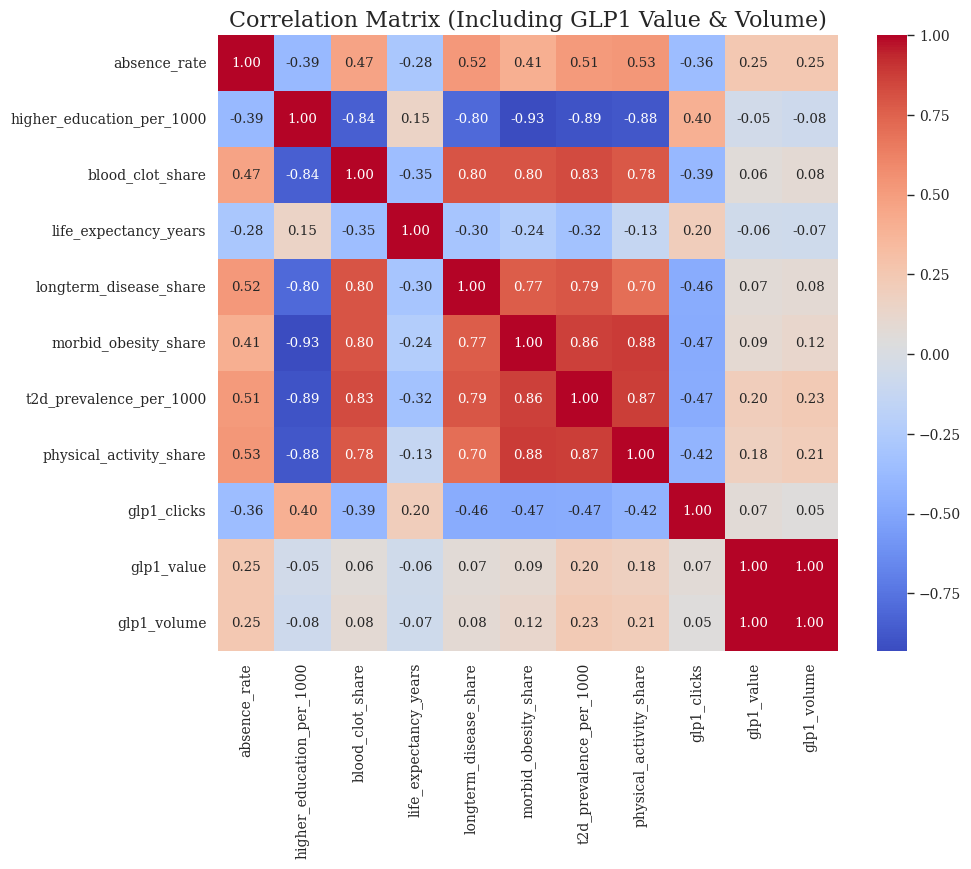

In [59]:
features = [
    "absence_rate","higher_education_per_1000","blood_clot_share","life_expectancy_years",
    "longterm_disease_share","morbid_obesity_share","t2d_prevalence_per_1000","physical_activity_share",
    "glp1_clicks","glp1_value","glp1_volume"
]

corr_matrix = master2[features].corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix (Including GLP1 Value & Volume)")
plt.show()


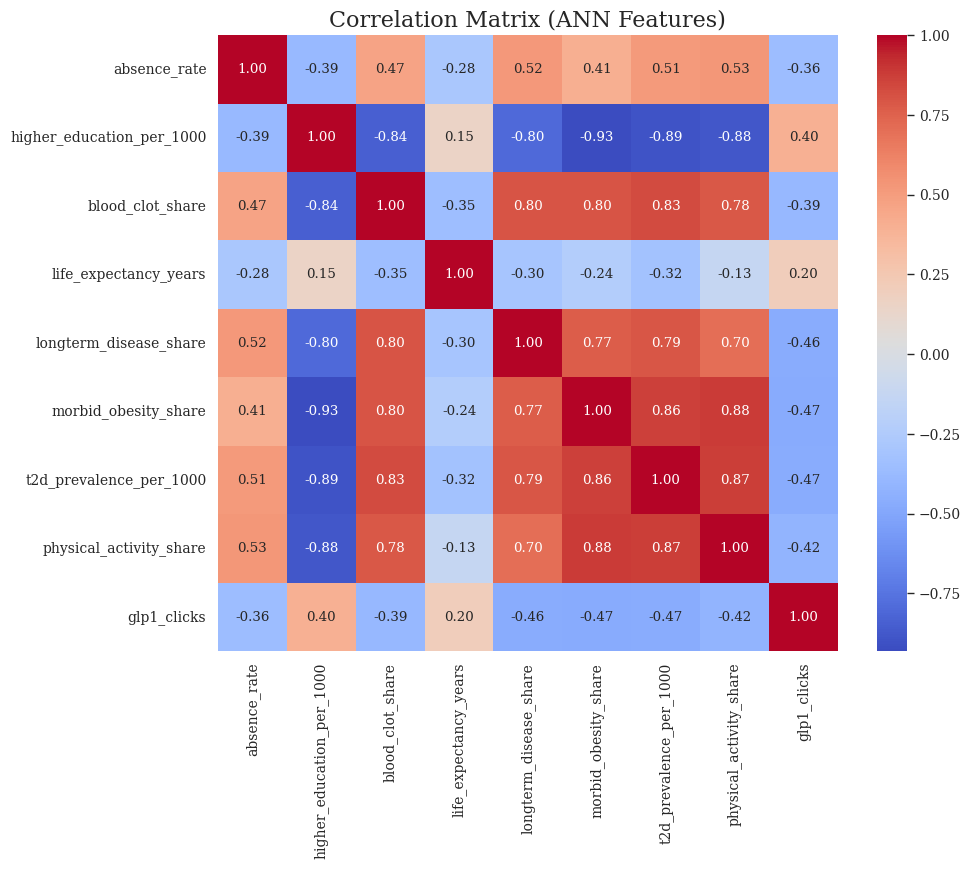

In [60]:
features = [
    "absence_rate","higher_education_per_1000","blood_clot_share","life_expectancy_years",
    "longterm_disease_share","morbid_obesity_share","t2d_prevalence_per_1000","physical_activity_share",
    "glp1_clicks"
]

corr_matrix = master2[features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix (ANN Features)")
plt.show()





The model

In [61]:
# Select features and target
features = [
    "absence_rate","higher_education_per_1000","blood_clot_share","life_expectancy_years",
    "longterm_disease_share","morbid_obesity_share","t2d_prevalence_per_1000","physical_activity_share",
    "glp1_clicks","glp1_value","glp1_volume"
]
X = master2[features].copy()
y = master2["untapped_market"].astype(int).copy()

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Balance training data
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print({"train_original": y_train.value_counts().to_dict(),
       "train_balanced": y_train_bal.value_counts().to_dict()})

# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_bal)
X_test_s  = scaler.transform(X_test)


{'train_original': {0: 33, 1: 9}, 'train_balanced': {0: 33, 1: 33}}


In [62]:
model = keras.Sequential([
    layers.Dense(32, activation="relu", input_shape=(X_train_s.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(
    X_train_s, y_train_bal,
    validation_data=(X_test_s, y_test),
    epochs=50,
    batch_size=16,
    verbose=1
)

# Save model (optional)
model.save("ann_untapped.keras")

Epoch 1/50


c:\Users\Natas\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.5606 - loss: 0.6690 - val_accuracy: 0.6111 - val_loss: 0.6166
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5606 - loss: 0.6486 - val_accuracy: 0.6111 - val_loss: 0.5918
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6970 - loss: 0.6059 - val_accuracy: 0.6667 - val_loss: 0.5694
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6818 - loss: 0.5695 - val_accuracy: 0.6667 - val_loss: 0.5496
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7727 - loss: 0.5545 - val_accuracy: 0.6667 - val_loss: 0.5353
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7727 - loss: 0.5214 - val_accuracy: 0.7222 - val_loss: 0.5236
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8636 - loss: 0.5052 - val_accuracy: 0.7222 - val_loss: 0.5165
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8939 - loss: 0.4621 - val_accuracy: 0.7778 - val_loss: 0.5112
Epoch 9/50


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Confusion Matrix:
 [[11  3]
 [ 0  4]]

Classification Report:
               precision    recall  f1-score   support

           0      1.000     0.786     0.880        14
           1      0.571     1.000     0.727         4

    accuracy                          0.833        18
   macro avg      0.786     0.893     0.804        18
weighted avg      0.905     0.833     0.846        18



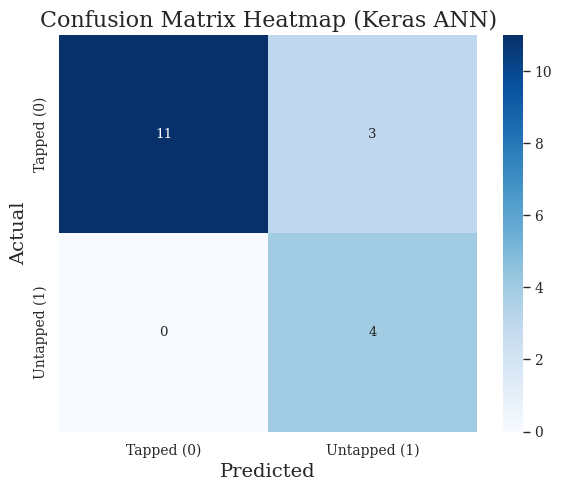

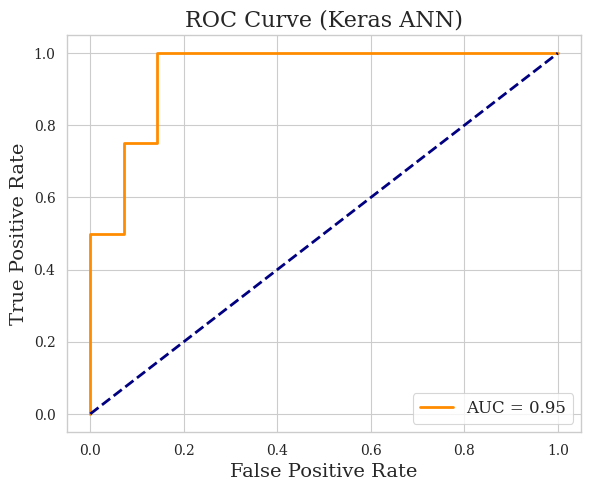

In [63]:
# Predictions: probabilities → binary labels
y_pred_prob = model.predict(X_test_s)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

# Confusion matrix and report
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))

# Confusion matrix heatmap
labels = ["Tapped (0)", "Untapped (1)"]
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap (Keras ANN)")
plt.tight_layout()
plt.show()

# ROC curve & AUC (use probabilities)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Keras ANN)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


Available keys in history: dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


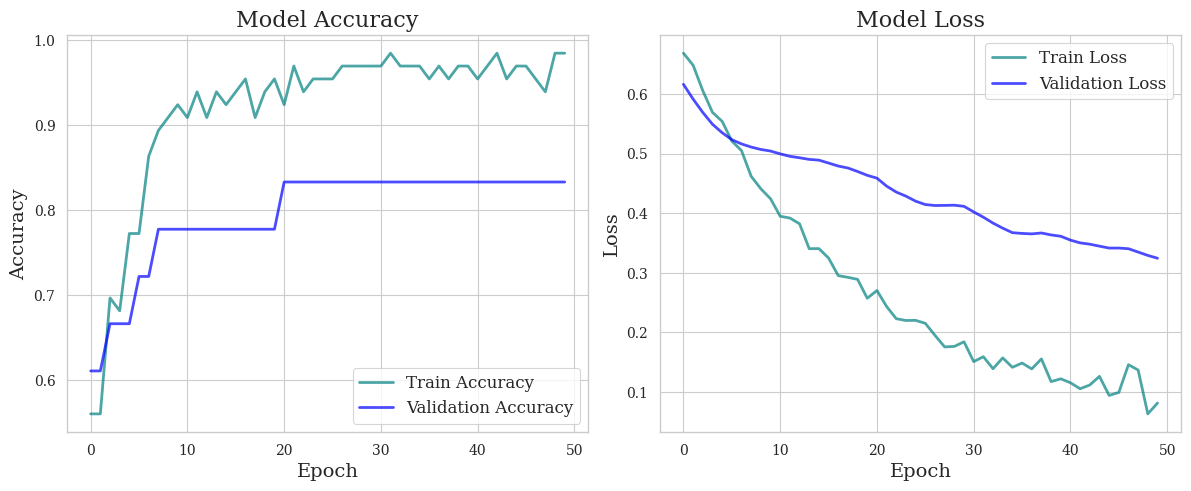

In [64]:
# Print available metrics in history
print("Available keys in history:", history.history.keys())

# Create side-by-side plots
fig, ax = plt.subplots(ncols=2, figsize=(12, 5))

# --- Accuracy plot ---
if 'accuracy' in history.history and 'val_accuracy' in history.history:
    ax[0].plot(history.history['accuracy'], label='Train Accuracy', color='teal', alpha=0.7)
    ax[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue', alpha=0.7)
    ax[0].set_title('Model Accuracy')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Accuracy')
    ax[0].legend(loc='lower right')
else:
    ax[0].text(0.5, 0.5, 'Accuracy data not available', ha='center', va='center')
    ax[0].set_title('Model Accuracy')

# --- Loss plot ---
if 'loss' in history.history and 'val_loss' in history.history:
    ax[1].plot(history.history['loss'], label='Train Loss', color='teal', alpha=0.7)
    ax[1].plot(history.history['val_loss'], label='Validation Loss', color='blue', alpha=0.7)
    ax[1].set_title('Model Loss')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Loss')
    ax[1].legend(loc='upper right')
else:
    ax[1].text(0.5, 0.5, 'Loss data not available', ha='center', va='center')
    ax[1].set_title('Model Loss')

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


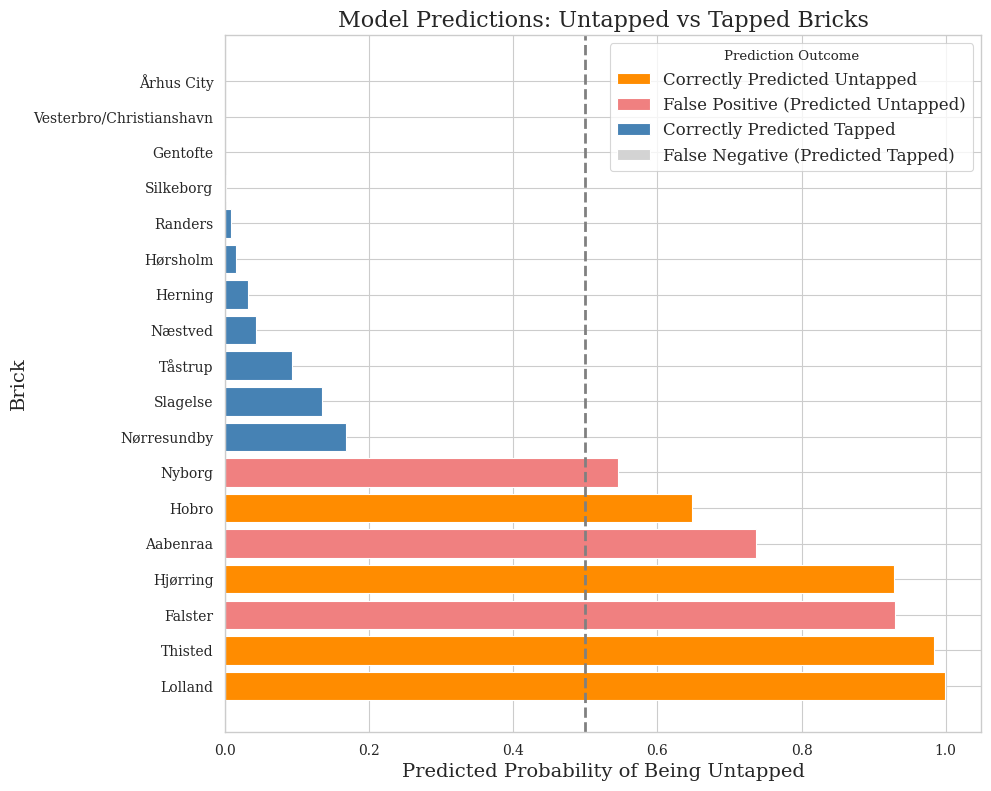

In [65]:
# --- Generate predictions ---
y_pred_prob = model.predict(X_test_s).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)  # adjust threshold if needed

# --- Build results DataFrame ---
df_results = pd.DataFrame({
    "brick": master2.loc[y_test.index, "brick"].values,
    "true_label": y_test.values,
    "predicted_prob": y_pred_prob,
    "predicted_class": y_pred
})

# --- Add correctness flag ---
df_results["correct"] = df_results["true_label"] == df_results["predicted_class"]

# --- Sort by predicted probability ---
df_sorted = df_results.sort_values("predicted_prob", ascending=False)

# --- Assign color based on prediction correctness ---
def assign_color(row):
    if row["predicted_class"] == 1 and row["correct"]:
        return "darkorange"  # correctly predicted untapped
    elif row["predicted_class"] == 1 and not row["correct"]:
        return "lightcoral"  # false positive (predicted untapped, actually tapped)
    elif row["predicted_class"] == 0 and row["correct"]:
        return "steelblue"   # correctly predicted tapped
    else:
        return "lightgray"   # false negative (predicted tapped, actually untapped)

df_sorted["color"] = df_sorted.apply(assign_color, axis=1)

# --- Plot horizontal bar chart ---
plt.figure(figsize=(10, 8))
plt.barh(df_sorted["brick"], df_sorted["predicted_prob"], color=df_sorted["color"])
plt.axvline(0.5, color="gray", linestyle="--", label="Threshold = 0.5")

plt.title("Model Predictions: Untapped vs Tapped Bricks")
plt.xlabel("Predicted Probability of Being Untapped")
plt.ylabel("Brick")

# --- Custom legend ---
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="darkorange", label="Correctly Predicted Untapped"),
    Patch(facecolor="lightcoral", label="False Positive (Predicted Untapped)"),
    Patch(facecolor="steelblue", label="Correctly Predicted Tapped"),
    Patch(facecolor="lightgray", label="False Negative (Predicted Tapped)")
]
plt.legend(handles=legend_elements, title="Prediction Outcome")

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


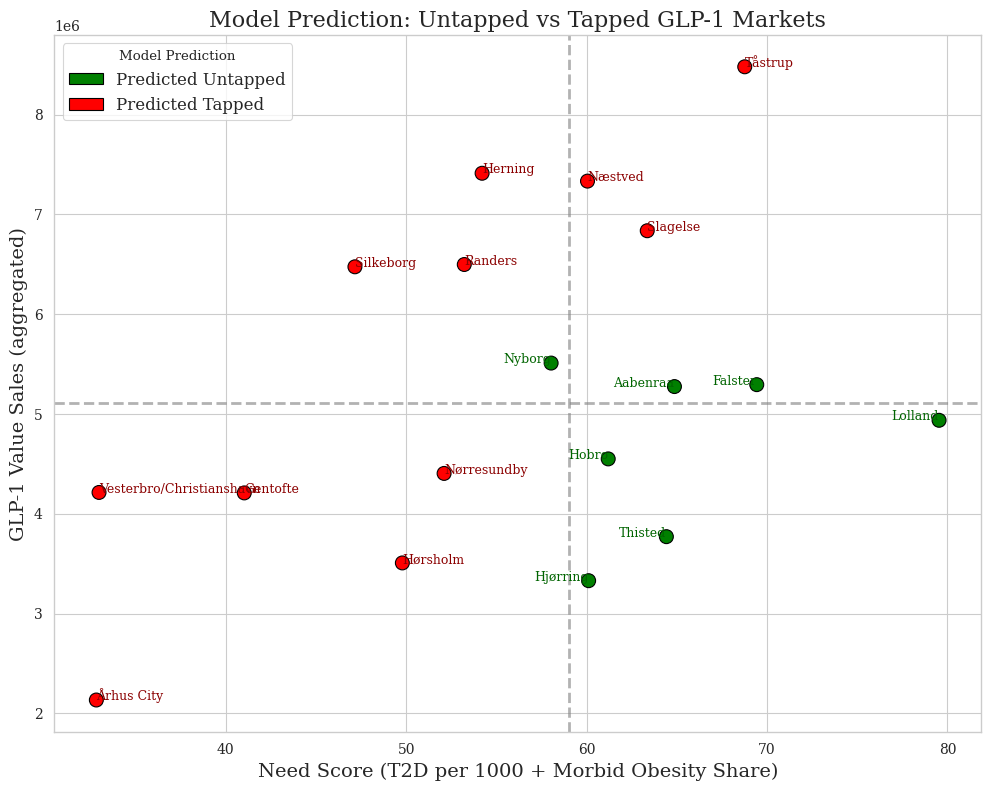

In [85]:
# --- Predict on test set ---
y_pred_prob = model.predict(X_test_s).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

# --- Build plotting DataFrame ---
df_plot = pd.DataFrame({
    "brick": master2.loc[y_test.index, "brick"].values,
    "need_score": master2.loc[y_test.index, "need_score"].values,
    "glp1_value": master2.loc[y_test.index, "glp1_value"].values,
    "predicted_class": y_pred,
    "predicted_prob": y_pred_prob
})

# --- Assign colors ---
df_plot["color"] = df_plot["predicted_class"].map({0: "red", 1: "green"})

# --- Plot ---
plt.figure(figsize=(10, 8))
plt.scatter(df_plot["need_score"], df_plot["glp1_value"],
            c=df_plot["color"], s=100, edgecolor="black")

# --- Add labels ---
for _, row in df_plot.iterrows():
    label_color = "darkgreen" if row["predicted_class"] == 1 else "darkred"
    ha = "right" if row["predicted_class"] == 1 else "left"
    plt.text(row["need_score"], row["glp1_value"], row["brick"],
             fontsize=9, ha=ha, color=label_color)

# --- Add quadrant lines based on test set ---
plt.axvline(df_plot["need_score"].median(), color="gray", linestyle="--", alpha=0.6)
plt.axhline(df_plot["glp1_value"].median(), color="gray", linestyle="--", alpha=0.6)

# --- Titles and labels ---
plt.title("Model Prediction: Untapped vs Tapped GLP-1 Markets")
plt.xlabel("Need Score (T2D per 1000 + Morbid Obesity Share)")
plt.ylabel("GLP-1 Value Sales (aggregated)")

# --- Legend ---
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="green", edgecolor="black", label="Predicted Untapped"),
    Patch(facecolor="red", edgecolor="black", label="Predicted Tapped")
]
plt.legend(handles=legend_elements, title="Model Prediction")

plt.tight_layout()
plt.show()

In [80]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,789 (10.90 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,860 (7.27 KB)

# More simpel architecture

In [67]:
def build_model(hidden_layer_sizes=(16,), activation="relu", learning_rate=0.001, dropout_rate=0.2):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_s.shape[1],)))

    for size in hidden_layer_sizes:
        model.add(layers.Dense(size, activation=activation))
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation="sigmoid"))

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [68]:
simple_model = build_model()
history = simple_model.fit(
    X_train_s, y_train_bal,
    validation_data=(X_test_s, y_test),
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.3485 - loss: 0.8375 - val_accuracy: 0.6667 - val_loss: 0.6593
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4394 - loss: 0.8218 - val_accuracy: 0.6667 - val_loss: 0.6358
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4242 - loss: 0.7839 - val_accuracy: 0.6667 - val_loss: 0.6147
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5303 - loss: 0.7003 - val_accuracy: 0.6667 - val_loss: 0.5961
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5758 - loss: 0.6676 - val_accuracy: 0.7222 - val_loss: 0.5796
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5455 - loss: 0.6885 - val_accuracy: 0.7222 - val_loss: 0.5653
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5303 - loss: 0.6834 - val_accuracy: 0.7222 - val_loss: 0.5517
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5606 - loss: 0.6332 - val_accuracy: 0.7222 - val_loss: 0.5399


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Confusion Matrix:
 [[10  4]
 [ 0  4]]

Classification Report:
               precision    recall  f1-score   support

           0      1.000     0.714     0.833        14
           1      0.500     1.000     0.667         4

    accuracy                          0.778        18
   macro avg      0.750     0.857     0.750        18
weighted avg      0.889     0.778     0.796        18



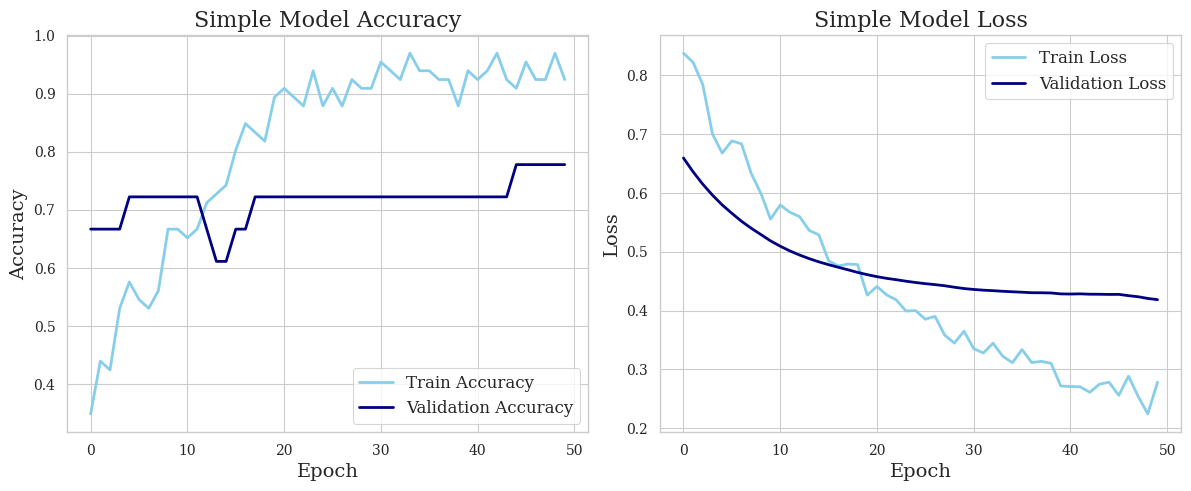

In [69]:
# Predict and threshold
y_pred_prob = simple_model.predict(X_test_s)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

# Metrics
from sklearn.metrics import classification_report, confusion_matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))

# Training curves
fig, ax = plt.subplots(ncols=2, figsize=(12, 5))
ax[0].plot(history.history['accuracy'], label='Train Accuracy', color='skyblue')
ax[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='navy')
ax[0].set_title('Simple Model Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

ax[1].plot(history.history['loss'], label='Train Loss', color='skyblue')
ax[1].plot(history.history['val_loss'], label='Validation Loss', color='navy')
ax[1].set_title('Simple Model Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


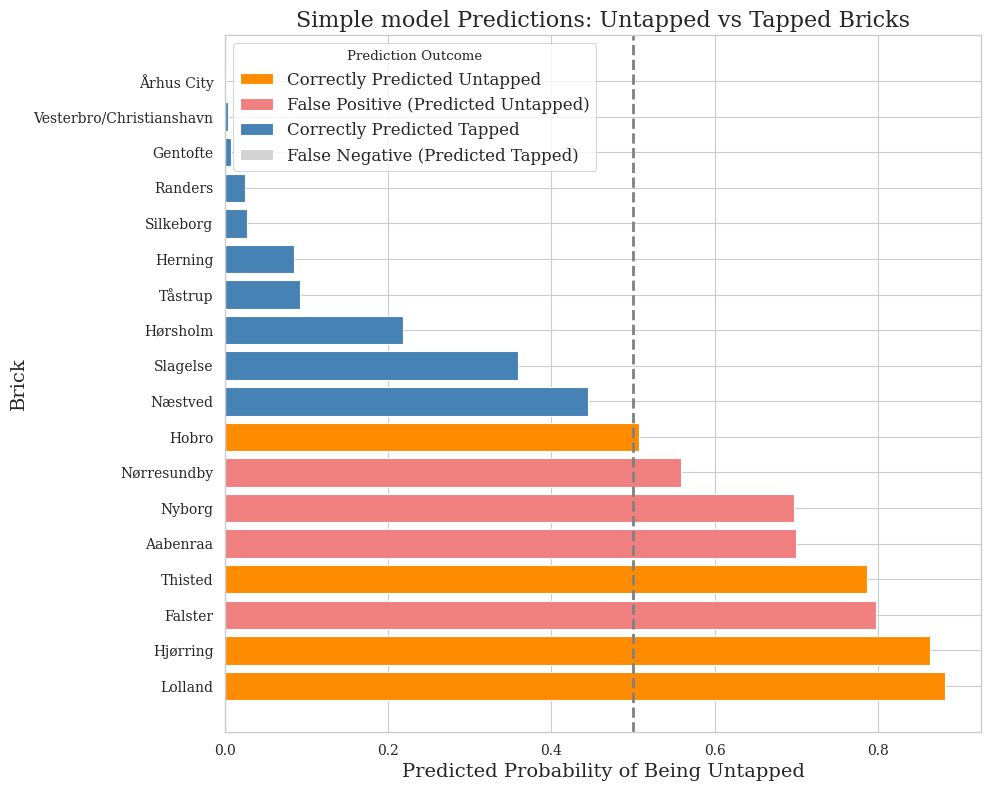

In [70]:
# --- Generate predictions ---
y_pred_prob = simple_model.predict(X_test_s).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)  # adjust threshold if needed

# --- Build results DataFrame ---
df_results = pd.DataFrame({
    "brick": master2.loc[y_test.index, "brick"].values,
    "true_label": y_test.values,
    "predicted_prob": y_pred_prob,
    "predicted_class": y_pred
})

# --- Add correctness flag ---
df_results["correct"] = df_results["true_label"] == df_results["predicted_class"]

# --- Sort by predicted probability ---
df_sorted = df_results.sort_values("predicted_prob", ascending=False)

# --- Assign color based on prediction correctness ---
def assign_color(row):
    if row["predicted_class"] == 1 and row["correct"]:
        return "darkorange"  # correctly predicted untapped
    elif row["predicted_class"] == 1 and not row["correct"]:
        return "lightcoral"  # false positive (predicted untapped, actually tapped)
    elif row["predicted_class"] == 0 and row["correct"]:
        return "steelblue"   # correctly predicted tapped
    else:
        return "lightgray"   # false negative (predicted tapped, actually untapped)

df_sorted["color"] = df_sorted.apply(assign_color, axis=1)

# --- Plot horizontal bar chart ---
plt.figure(figsize=(10, 8))
plt.barh(df_sorted["brick"], df_sorted["predicted_prob"], color=df_sorted["color"])
plt.axvline(0.5, color="gray", linestyle="--", label="Threshold = 0.5")

plt.title("Simple model Predictions: Untapped vs Tapped Bricks")
plt.xlabel("Predicted Probability of Being Untapped")
plt.ylabel("Brick")

# --- Custom legend ---
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="darkorange", label="Correctly Predicted Untapped"),
    Patch(facecolor="lightcoral", label="False Positive (Predicted Untapped)"),
    Patch(facecolor="steelblue", label="Correctly Predicted Tapped"),
    Patch(facecolor="lightgray", label="False Negative (Predicted Tapped)")
]
plt.legend(handles=legend_elements, title="Prediction Outcome")

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


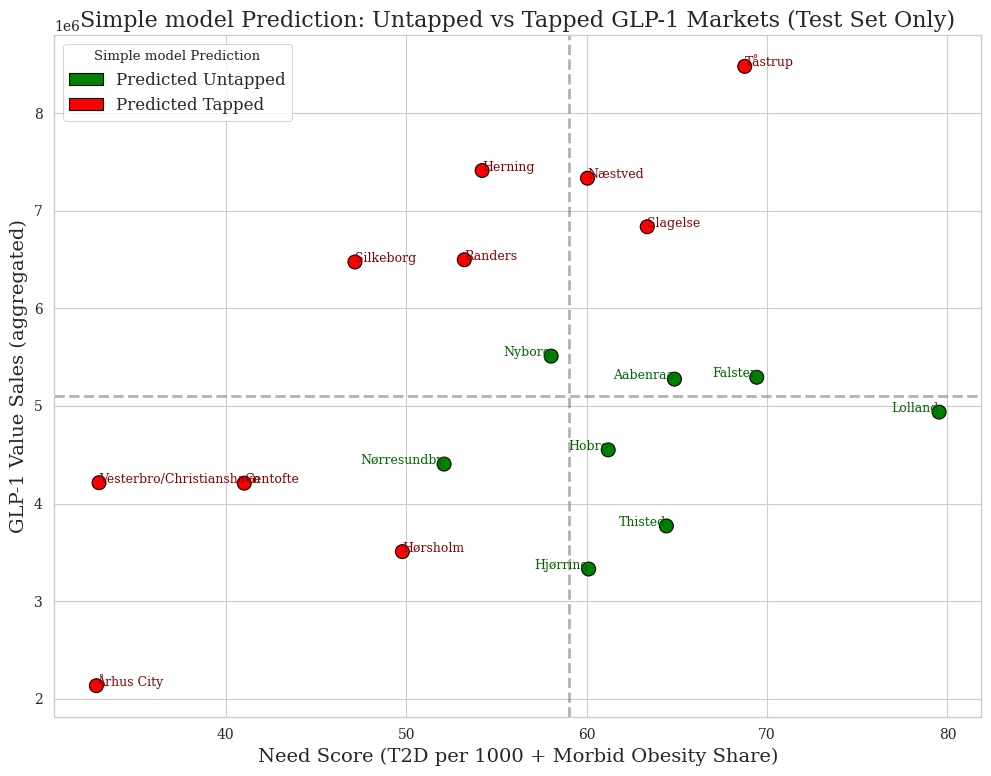

In [71]:
# --- Predict on test set ---
y_pred_prob = simple_model.predict(X_test_s).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

# --- Build plotting DataFrame ---
df_plot = pd.DataFrame({
    "brick": master2.loc[y_test.index, "brick"].values,
    "need_score": master2.loc[y_test.index, "need_score"].values,
    "glp1_value": master2.loc[y_test.index, "glp1_value"].values,
    "predicted_class": y_pred,
    "predicted_prob": y_pred_prob
})

# --- Assign colors ---
df_plot["color"] = df_plot["predicted_class"].map({0: "red", 1: "green"})

# --- Plot ---
plt.figure(figsize=(10, 8))
plt.scatter(df_plot["need_score"], df_plot["glp1_value"],
            c=df_plot["color"], s=100, edgecolor="black")

# --- Add labels ---
for _, row in df_plot.iterrows():
    label_color = "darkgreen" if row["predicted_class"] == 1 else "darkred"
    ha = "right" if row["predicted_class"] == 1 else "left"
    plt.text(row["need_score"], row["glp1_value"], row["brick"],
             fontsize=9, ha=ha, color=label_color)

# --- Add quadrant lines based on test set ---
plt.axvline(df_plot["need_score"].median(), color="gray", linestyle="--", alpha=0.6)
plt.axhline(df_plot["glp1_value"].median(), color="gray", linestyle="--", alpha=0.6)

# --- Titles and labels ---
plt.title("Simple model Prediction: Untapped vs Tapped GLP-1 Markets (Test Set Only)")
plt.xlabel("Need Score (T2D per 1000 + Morbid Obesity Share)")
plt.ylabel("GLP-1 Value Sales (aggregated)")

# --- Legend ---
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="green", edgecolor="black", label="Predicted Untapped"),
    Patch(facecolor="red", edgecolor="black", label="Predicted Tapped")
]
plt.legend(handles=legend_elements, title="Simple model Prediction")

plt.tight_layout()
plt.show()

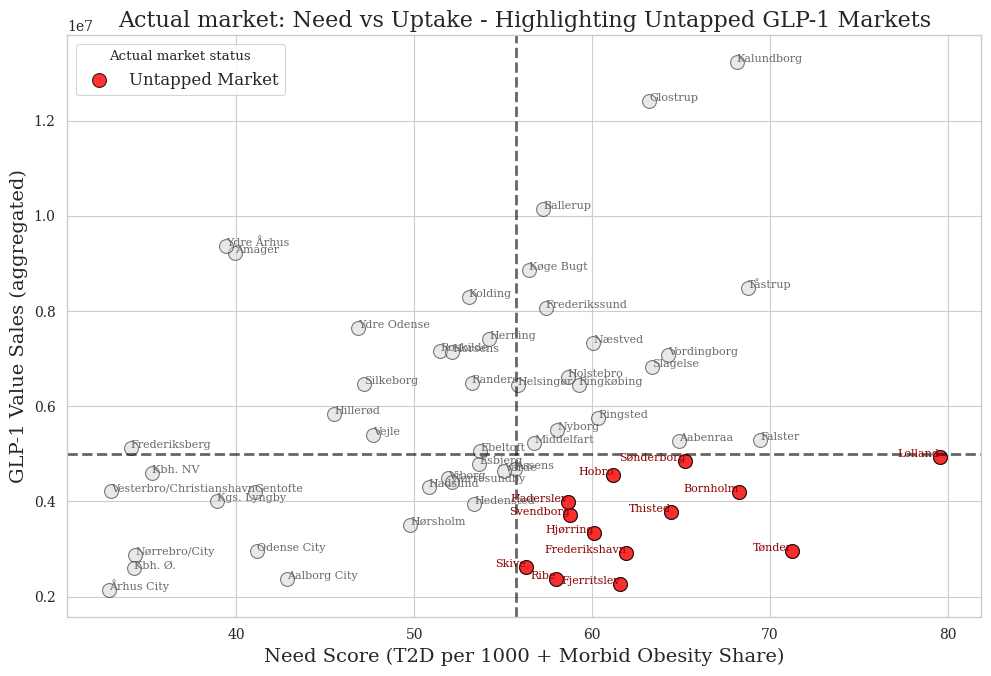

In [86]:
import matplotlib.pyplot as plt

# Calculate medians
need_median = master2["need_score"].median()
uptake_median = master2["glp1_value"].median()

# Assign untapped flag
master2["untapped_flag"] = (
    (master2["need_score"] >= need_median) & 
    (master2["glp1_value"] < uptake_median)
)

# Plot
plt.figure(figsize=(10, 7))

# Plot all bricks in gray
plt.scatter(master2["need_score"], master2["glp1_value"],
            c="lightgray", alpha=0.5, edgecolor="black", s=100)

# Highlight untapped in red
plt.scatter(master2.loc[master2["untapped_flag"], "need_score"],
            master2.loc[master2["untapped_flag"], "glp1_value"],
            c="red", label="Untapped Market", alpha=0.8, edgecolor="black", s=100)

# Add labels for all bricks
for _, row in master2.iterrows():
    label_color = "darkred" if row["untapped_flag"] else "dimgray"
    ha = "right" if row["untapped_flag"] else "left"
    plt.text(row["need_score"], row["glp1_value"], row["brick"],
             fontsize=8, ha=ha, color=label_color)

# Add quadrant lines
plt.axvline(need_median, color="black", linestyle="--", alpha=0.6)
plt.axhline(uptake_median, color="black", linestyle="--", alpha=0.6)

# Labels and legend
plt.xlabel("Need Score (T2D per 1000 + Morbid Obesity Share)")
plt.ylabel("GLP-1 Value Sales (aggregated)")
plt.title("Actual market: Need vs Uptake - Highlighting Untapped GLP-1 Markets")
plt.legend(title="Actual market status")
plt.tight_layout()
plt.show()

In [73]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Predict with both models
y_pred_model = (model.predict(X_test_s).ravel() > 0.5).astype(int)
y_pred_simple = (simple_model.predict(X_test_s).ravel() > 0.5).astype(int)

# Probabilities for AUC
y_prob_model = model.predict(X_test_s).ravel()
y_prob_simple = simple_model.predict(X_test_s).ravel()

# Print comparison
print("=== Complex Model ===")
print(classification_report(y_test, y_pred_model))
print("AUC:", roc_auc_score(y_test, y_prob_model))

print("\n=== Simple Model ===")
print(classification_report(y_test, y_pred_simple))
print("AUC:", roc_auc_score(y_test, y_prob_simple))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
=== Complex Model ===
              precision    recall  f1-score   support

           0       1.00      0.79      0.88        14
           1       0.57      1.00      0.73         4

    accuracy                           0.83        18
   macro avg       0.79      0.89      0.80        18
weighted avg       0.90      0.83      0.85        18

AUC: 0.9464285714285715

=== Simple Model ===
              precision    recall  f1-score   support

           0       1.00      0.71      0.83        14
           1       0.50      1.00      0.67         4

    accuracy                           0.78        18
   macro avg       0.75      0.86      0.75        18
weighted avg       0.89      0.78      0.80        18

AUC: 0.9107142857142857


In [74]:
df_compare = pd.DataFrame({
    "brick": master2.loc[y_test.index, "brick"].values,
    "true_label": y_test.values,
    "model_pred": y_pred_model,
    "simple_pred": y_pred_simple,
    "model_prob": y_prob_model,
    "simple_prob": y_prob_simple
})

# Add flags
df_compare["agreement"] = df_compare["model_pred"] == df_compare["simple_pred"]
df_compare["model_correct"] = df_compare["model_pred"] == df_compare["true_label"]
df_compare["simple_correct"] = df_compare["simple_pred"] == df_compare["true_label"]


In [75]:
def assign_color(row):
    if row["agreement"] and row["model_correct"] and row["simple_correct"]:
        return "green"  # both correct
    elif row["agreement"] and not row["model_correct"] and not row["simple_correct"]:
        return "red"    # both wrong
    elif not row["agreement"] and row["model_correct"]:
        return "blue"   # model correct, simple wrong
    elif not row["agreement"] and row["simple_correct"]:
        return "orange" # simple correct, model wrong
    else:
        return "gray"   # disagreement, both wrong

df_compare["color"] = df_compare.apply(assign_color, axis=1)

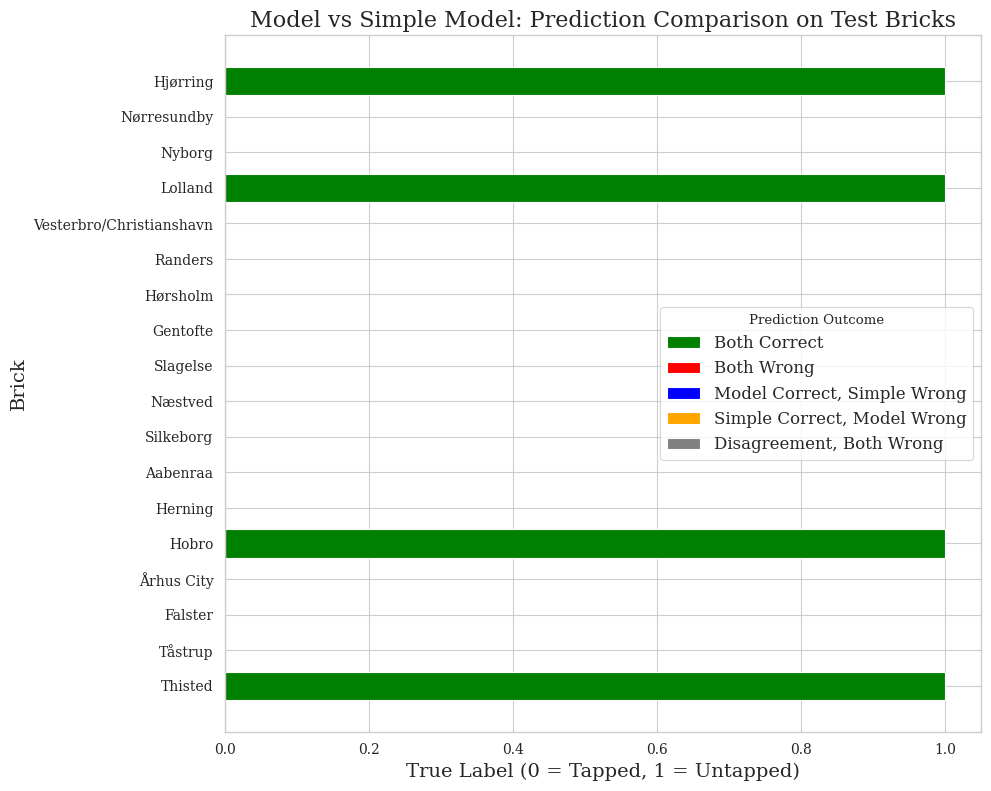

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.barh(df_compare["brick"], df_compare["true_label"], color=df_compare["color"])

plt.title("Model vs Simple Model: Prediction Comparison on Test Bricks")
plt.xlabel("True Label (0 = Tapped, 1 = Untapped)")
plt.ylabel("Brick")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="green", label="Both Correct"),
    Patch(facecolor="red", label="Both Wrong"),
    Patch(facecolor="blue", label="Model Correct, Simple Wrong"),
    Patch(facecolor="orange", label="Simple Correct, Model Wrong"),
    Patch(facecolor="gray", label="Disagreement, Both Wrong")
]
plt.legend(handles=legend_elements, title="Prediction Outcome")
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


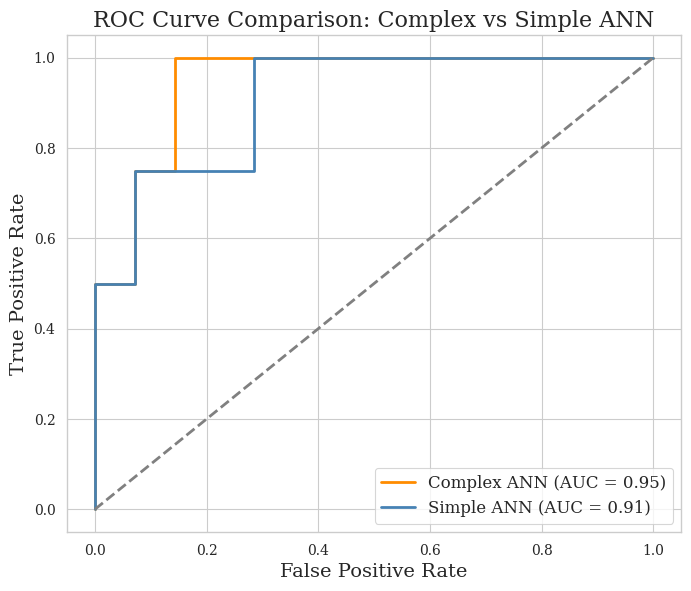

In [77]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# --- Predict probabilities for both models ---
y_prob_model = model.predict(X_test_s).ravel()
y_prob_simple = simple_model.predict(X_test_s).ravel()

# --- Compute ROC curve and AUC ---
fpr_model, tpr_model, _ = roc_curve(y_test, y_prob_model)
roc_auc_model = auc(fpr_model, tpr_model)

fpr_simple, tpr_simple, _ = roc_curve(y_test, y_prob_simple)
roc_auc_simple = auc(fpr_simple, tpr_simple)

# --- Plot both curves ---
plt.figure(figsize=(7,6))
plt.plot(fpr_model, tpr_model, color="darkorange", lw=2,
         label=f"Complex ANN (AUC = {roc_auc_model:.2f})")
plt.plot(fpr_simple, tpr_simple, color="steelblue", lw=2,
         label=f"Simple ANN (AUC = {roc_auc_simple:.2f})")

# Diagonal baseline
plt.plot([0,1], [0,1], color="gray", linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Complex vs Simple ANN")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


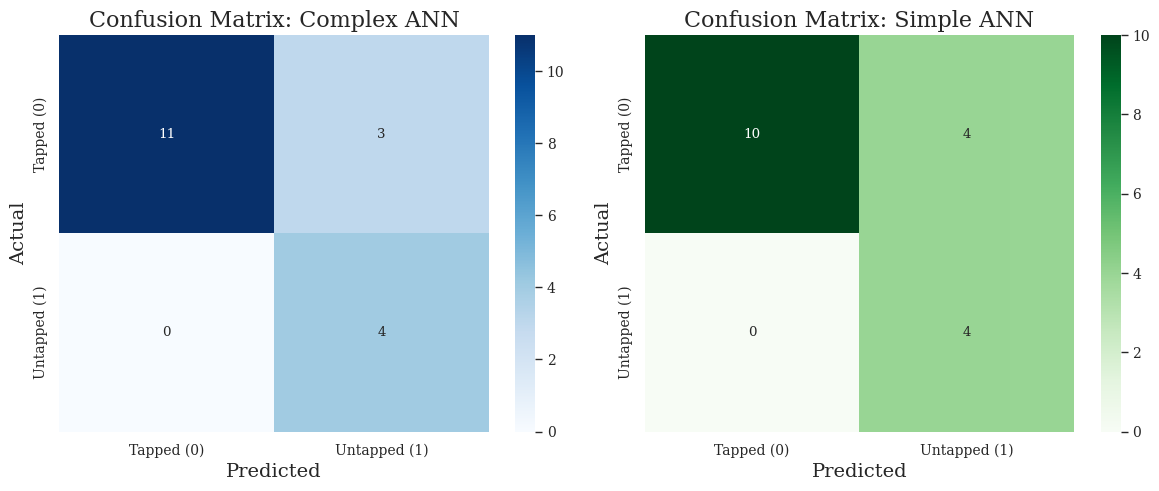

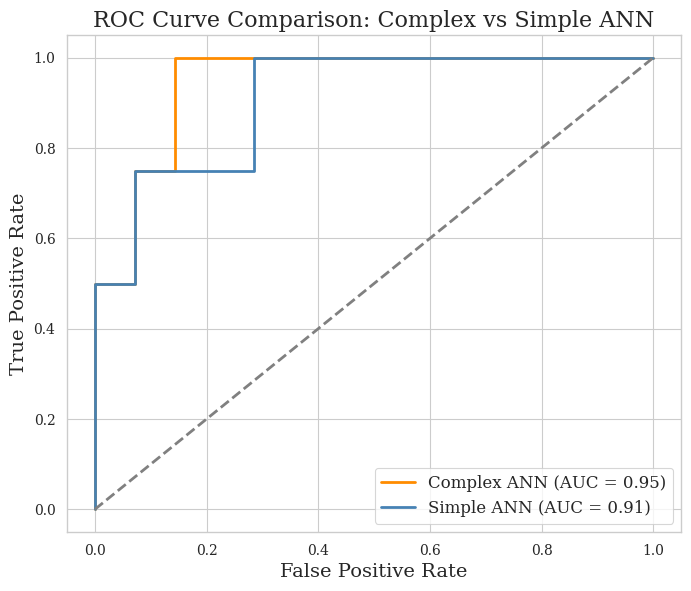

=== Complex ANN ===
              precision    recall  f1-score   support

           0       1.00      0.79      0.88        14
           1       0.57      1.00      0.73         4

    accuracy                           0.83        18
   macro avg       0.79      0.89      0.80        18
weighted avg       0.90      0.83      0.85        18


=== Simple ANN ===
              precision    recall  f1-score   support

           0       1.00      0.71      0.83        14
           1       0.50      1.00      0.67         4

    accuracy                           0.78        18
   macro avg       0.75      0.86      0.75        18
weighted avg       0.89      0.78      0.80        18



In [78]:
# --- Predictions for both models ---
y_prob_model = model.predict(X_test_s).ravel()
y_pred_model = (y_prob_model > 0.5).astype(int)

y_prob_simple = simple_model.predict(X_test_s).ravel()
y_pred_simple = (y_prob_simple > 0.5).astype(int)

# --- Confusion matrices ---
cm_model = confusion_matrix(y_test, y_pred_model)
cm_simple = confusion_matrix(y_test, y_pred_simple)

labels = ["Tapped (0)", "Untapped (1)"]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(cm_model, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix: Complex ANN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1,2,2)
sns.heatmap(cm_simple, annot=True, fmt="d", cmap="Greens",
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix: Simple ANN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# --- ROC curves ---
fpr_model, tpr_model, _ = roc_curve(y_test, y_prob_model)
roc_auc_model = auc(fpr_model, tpr_model)

fpr_simple, tpr_simple, _ = roc_curve(y_test, y_prob_simple)
roc_auc_simple = auc(fpr_simple, tpr_simple)

plt.figure(figsize=(7,6))
plt.plot(fpr_model, tpr_model, color="darkorange", lw=2,
         label=f"Complex ANN (AUC = {roc_auc_model:.2f})")
plt.plot(fpr_simple, tpr_simple, color="steelblue", lw=2,
         label=f"Simple ANN (AUC = {roc_auc_simple:.2f})")
plt.plot([0,1], [0,1], color="gray", linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Complex vs Simple ANN")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# --- Classification reports ---
print("=== Complex ANN ===")
print(classification_report(y_test, y_pred_model))

print("\n=== Simple ANN ===")
print(classification_report(y_test, y_pred_simple))